Setting up the workspace by importing libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

np.random.seed(123)


Setting up the working directory

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/MGMT 52500')

In [4]:
df = pd.read_csv('Spatial_Temporal_Revenue_Efficiency.csv')
df.head()

,pickup_borough,pickup_zone,total_trips,total_revenue,revenue_per_mile,revenue_per_minute
0,"""EWR""","""Newark Airport""",55,4171.89,11.062793,11.398607
1,"""Staten Island""","""Arden Heights""",1,171.30,15.432432,9.516667
2,"""EWR""","""Newark Airport""",79,6170.25,12.914417,9.507319
3,"""Staten Island""","""Arden Heights""",1,79.68,419.368421,7.968000
4,"""Bronx""","""Pelham Bay Park""",10,1107.20,8.343004,7.007595


1) Spatial-Temporal Revenue Efficiency


*   Which specific taxi zones and corridors yield the highest revenue efficiency (revenue per mile and revenue per minute), and how do these high-value zones shift across different times of day (peak vs off peak hours) and days of the week?




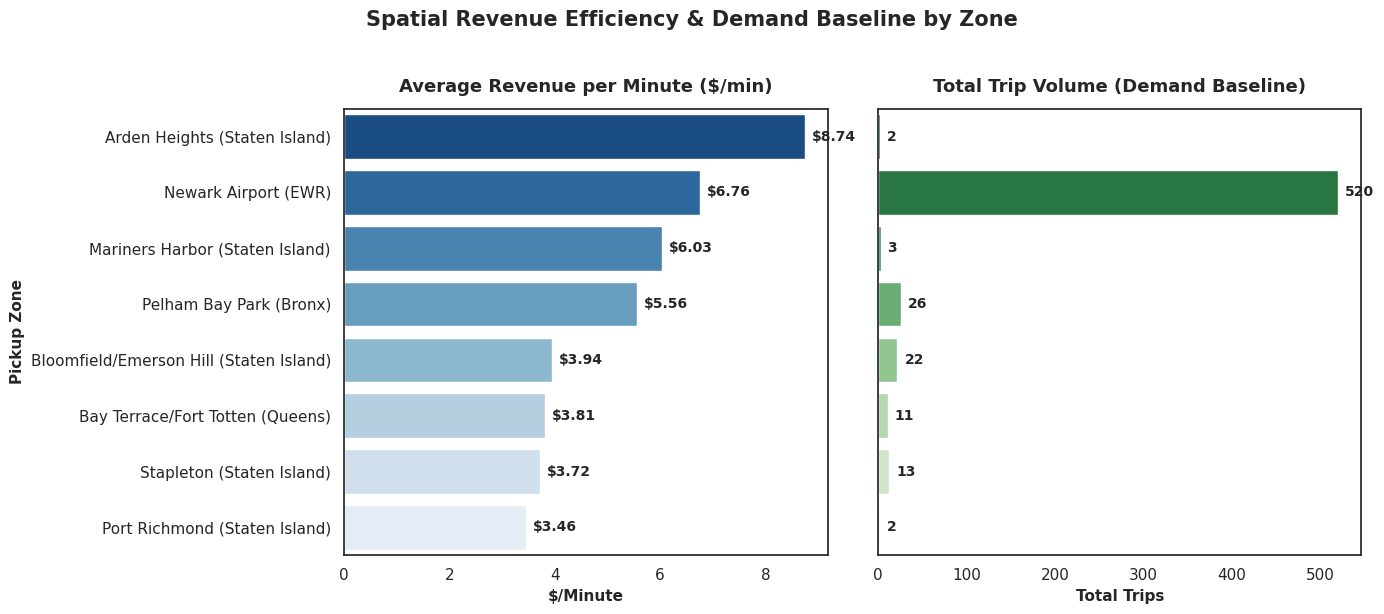

In [6]:
# 2. Clean Athena string quotation marks and whitespace
df['pickup_borough'] = df['pickup_borough'].str.replace('"', '').str.strip()
df['pickup_zone'] = df['pickup_zone'].str.replace('"', '').str.strip()

# 3. Aggregate data across zones to calculate totals and average efficiency
df_aggregated = df.groupby(['pickup_borough', 'pickup_zone'], as_index=False).agg(
    total_trips=('total_trips', 'sum'),
    total_revenue=('total_revenue', 'sum'),
    revenue_per_minute=('revenue_per_minute', 'mean'),
    revenue_per_mile=('revenue_per_mile', 'mean')
).sort_values(by='revenue_per_minute', ascending=False)

# Select top zones for visualization
df_top = df_aggregated.head(8).copy()
df_top['zone_label'] = df_top['pickup_zone'] + ' (' + df_top['pickup_borough'] + ')'

# 4. Create Side-by-Side Subplots
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot A: Revenue per Minute Efficiency
sns.barplot(
    data=df_top,
    x='revenue_per_minute',
    y='zone_label',
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Average Revenue per Minute ($/min)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('$/Minute', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pickup Zone', fontsize=11, fontweight='bold')

# Add data value labels
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'${width:.2f}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                     fontsize=10, fontweight='bold')

# Plot B: Total Trip Volume Context
sns.barplot(
    data=df_top,
    x='total_trips',
    y='zone_label',
    palette='Greens_r',
    ax=axes[1]
)
axes[1].set_title('Total Trip Volume (Demand Baseline)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Total Trips', fontsize=11, fontweight='bold')
axes[1].set_ylabel('')

# Add data value labels
for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f'{int(width):,}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                     fontsize=10, fontweight='bold')

plt.suptitle('Spatial Revenue Efficiency & Demand Baseline by Zone', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

2) Year-over-Year (YoY) Consumer Behavior & Tipping Dynamics


*   How did passenger tipping behavior and payment preference (credit card vs cash) shift between Q1 2015 and Q1 2016 across different boroughs, and how did tip percentages impact overall driver compensation?



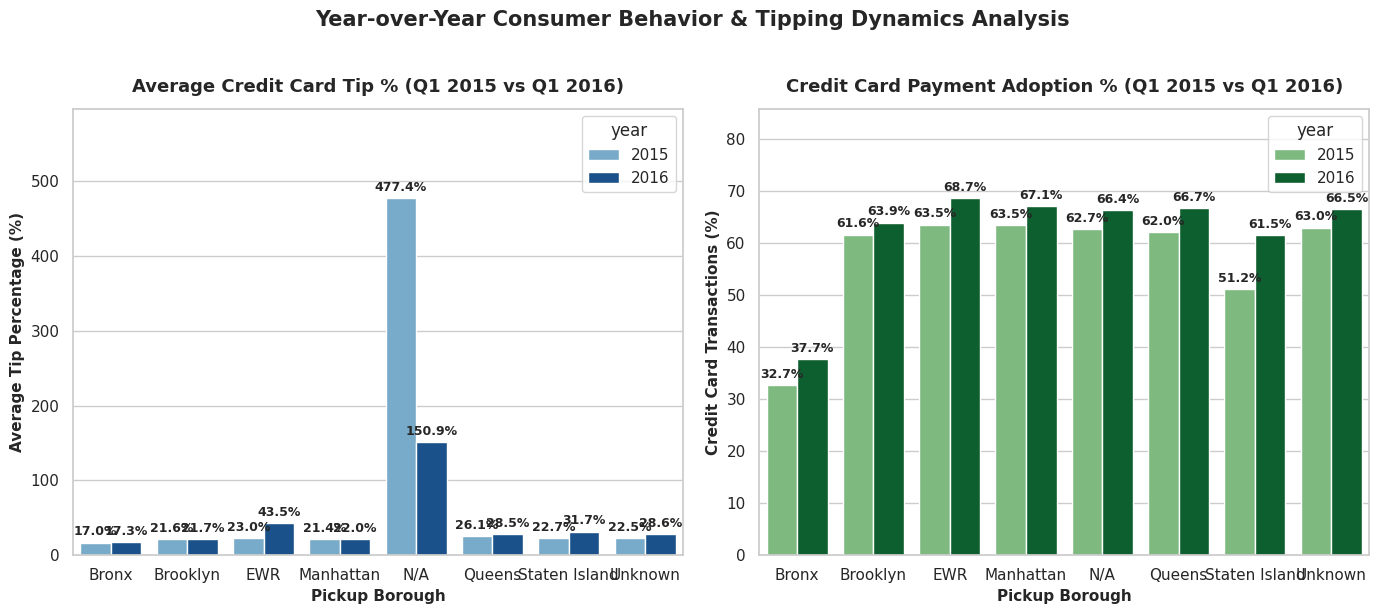

In [7]:
# 1. Load the exported Athena query CSV for YoY analysis
df = pd.read_csv('Year_Over_Year_Consumer_Behavior.csv')

# Clean quotation marks or whitespace if present from raw CSV exports
if df['pickup_borough'].dtype == 'object':
    df['pickup_borough'] = df['pickup_borough'].str.replace('"', '').str.strip()

# 2. Aggregate metrics by Borough and Year
yoy_summary = df.groupby(['pickup_borough', 'year'], as_index=False).agg(
    avg_cc_tip_pct=('avg_cc_tip_pct', 'mean'),
    avg_credit_card_pct=('credit_card_pct', 'mean')
)

# 3. Setup Side-by-Side Grouped Subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Average Tip % (2015 vs 2016)
sns.barplot(
    data=yoy_summary,
    x='pickup_borough',
    y='avg_cc_tip_pct',
    hue='year',
    palette=['#6baed6', '#08519c'],
    ax=axes[0]
)
axes[0].set_title('Average Credit Card Tip % (Q1 2015 vs Q1 2016)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Pickup Borough', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Tip Percentage (%)', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(yoy_summary['avg_cc_tip_pct']) * 1.25)

# Add data percentage labels
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', xytext=(0, 3),
                         textcoords='offset points', fontsize=9, fontweight='bold')

# Subplot 2: Credit Card Adoption Rate % (2015 vs 2016)
sns.barplot(
    data=yoy_summary,
    x='pickup_borough',
    y='avg_credit_card_pct',
    hue='year',
    palette=['#74c476', '#006d2c'],
    ax=axes[1]
)
axes[1].set_title('Credit Card Payment Adoption % (Q1 2015 vs Q1 2016)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Pickup Borough', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Credit Card Transactions (%)', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, max(yoy_summary['avg_credit_card_pct']) * 1.25)

# Add data percentage labels
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', xytext=(0, 3),
                         textcoords='offset points', fontsize=9, fontweight='bold')

plt.suptitle('Year-over-Year Consumer Behavior & Tipping Dynamics Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()